# EDA and data cleaning

In [28]:
%load_ext autoreload
%autoreload 2
import sys
import os

# 1. Get the directory of the current notebook
notebook_dir = os.path.abspath('')

# 2. Go up two levels to reach the 'src' root directory
src_root = os.path.abspath(os.path.join(notebook_dir, '..'))

# 3. Target the 'utils' folder exactly
utils_path = os.path.join(src_root, 'utils')

# 4. Append to sys.path if it's not already there
if utils_path not in sys.path:
    sys.path.append(utils_path)

#  FORCE CACHE CLEAR: Manually evict the old module version from Python's memory
if 'eda_and_data_cleaning' in sys.modules:
    del sys.modules['eda_and_data_cleaning']

print(f"Added to path: {utils_path}")

# 5. Import your functions seamlessly
from eda_and_data_cleaning import (
    summarize_dataset_structure, 
    drop_missing_landmark_frames, 
    plot_feature_variance_by_class, 
    plot_feature_collinearity_matrix, 
    plot_signal_stability_over_time
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Added to path: d:\YogAi_Models_Refactor\src\utils


In [52]:

raw_warrior2_df = summarize_dataset_structure("../../data/processed/engineered_features/warrior2_pose/warrior2_pose_features.csv")


       RESEARCH COMPREHENSIVE PROFILE: ../../data/processed/engineered_features/warrior2_pose/warrior2_pose_features.csv               
 DATASET DIMENSIONS:
   - Total Recorded Frames (Rows): 5372
   - Total Columns: 12
   - Biomechanical Features Detected (9): ['back_knee_flexion_angle', 'front_knee_flexion_angle', 'spine_hip_angle', 'stance_width_normalized', 'front_knee_ankle_alignment', 'center_of_mass_torso_offset', 'wrist_height_symmetry', 'front_wrist_shoulder_vertical_offset', 'back_wrist_shoulder_vertical_offset']

 FEATURE DESCRIPTIVE STATISTICS (ANGLES/DISTANCES):


,mean,std,min,max
back_knee_flexion_angle,171.442177,11.702572,1.722040e+01,179.606756
front_knee_flexion_angle,137.815471,19.035377,5.336107e+01,179.557175
spine_hip_angle,103.632433,7.027147,4.807122e+01,137.484687
stance_width_normalized,2.552282,1.588448,5.037249e-01,111.480780
front_knee_ankle_alignment,0.140964,0.532184,3.764161e-05,37.948181
center_of_mass_torso_offset,0.152492,0.183101,4.783918e-07,3.774383
wrist_height_symmetry,0.275649,0.273960,1.147521e-05,3.308761
front_wrist_shoulder_vertical_offset,0.347328,0.552012,8.860115e-06,32.535405
back_wrist_shoulder_vertical_offset,0.465792,0.594635,1.372977e-04,35.304698




 LABEL/CLASS DISTRIBUTION (Target Balance):
   - Class 'back_leg_bent': 900 frames (16.75%)
   - Class 'drooping_arms': 900 frames (16.75%)
   - Class 'knee_caved': 900 frames (16.75%)
   - Class 'shallow_stance': 900 frames (16.75%)
   - Class 'leaning_torso': 899 frames (16.73%)
   - Class 'correct': 873 frames (16.25%)


📹 VIDEO SOURCE DISTRIBUTION (Data Diversity):
   - Total unique video sources: 313
   - Frames per top sources:
source_id
back_leg_bent-3.mp4       225
back_leg_bent-4.mp4       225
back_leg_bent_1.mp4       225
back_leg_bent_2.mp4       225
warrior2-correct-4.mp4    225

🔍 LANDMARK DROP/MISSING VALUE PROFILE:
   - Phenomenal! Zero missing values detected in the raw dataset.



In [53]:

# Run Targeted Structural Cleaning
cleaned_warrior2_df = drop_missing_landmark_frames(raw_warrior2_df)


[CLEANING] Dropped 0 frames due to incomplete landmark tracking.
[CLEANING] Remaining stable frames: 5372


In [54]:
# Count before filtering
initial_count = len(cleaned_warrior2_df)

# Apply the outlier filter
cleaned_warrior2_df = cleaned_warrior2_df[cleaned_warrior2_df['stance_width_normalized'] < 5.0]

# Count after filtering
final_count = len(cleaned_warrior2_df)
dropped_count = initial_count - final_count

# Print the breakdown nicely
print(f"--- Stance Width Outlier Removal Summary ---")
print(f"Initial row count: {initial_count}")
print(f"Rows dropped (stance width >= 5.0): {dropped_count}")
print(f"Final cleaned row count: {final_count}")
print(f"--------------------------------------------")

--- Stance Width Outlier Removal Summary ---
Initial row count: 5372
Rows dropped (stance width >= 5.0): 14
Final cleaned row count: 5358
--------------------------------------------


In [55]:
# Drop rows where normalized stance width is unrealistically high (e.g., > 5.0)
cleaned_warrior2_df = cleaned_warrior2_df[cleaned_warrior2_df['stance_width_normalized'] < 5.0]

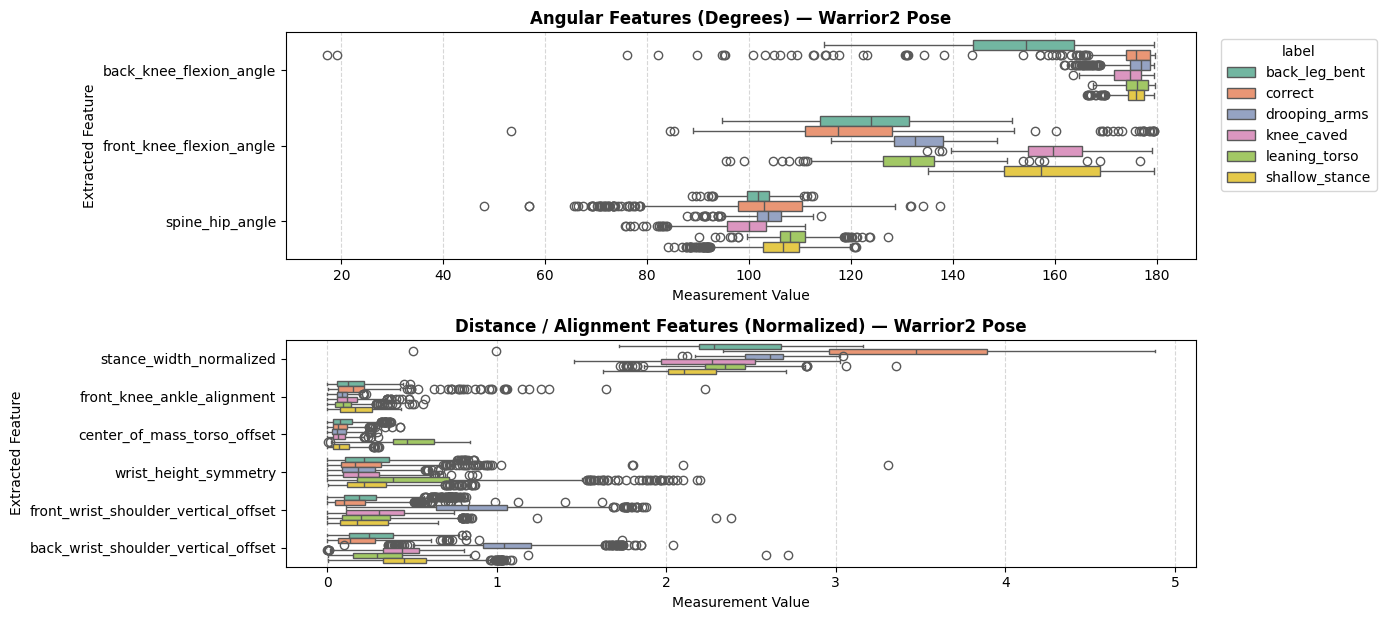

In [56]:

# Visualization
plot_feature_variance_by_class(cleaned_warrior2_df, pose_name="Warrior2 Pose")


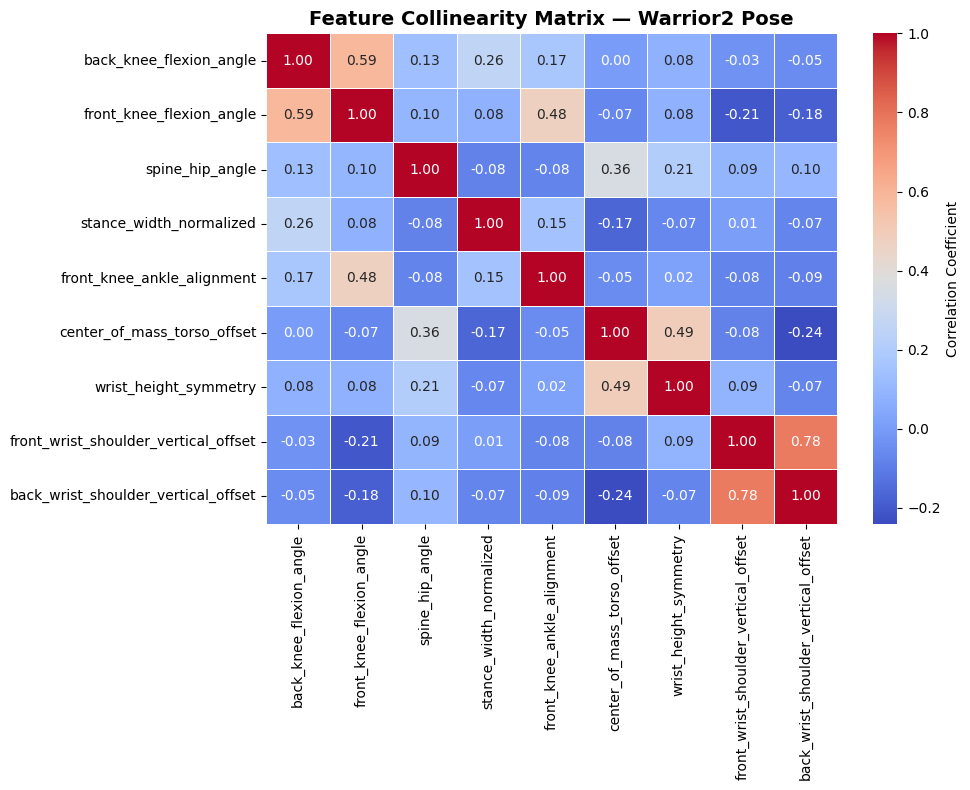

In [51]:
plot_feature_collinearity_matrix(cleaned_warrior2_df, pose_name="Warrior2 Pose")

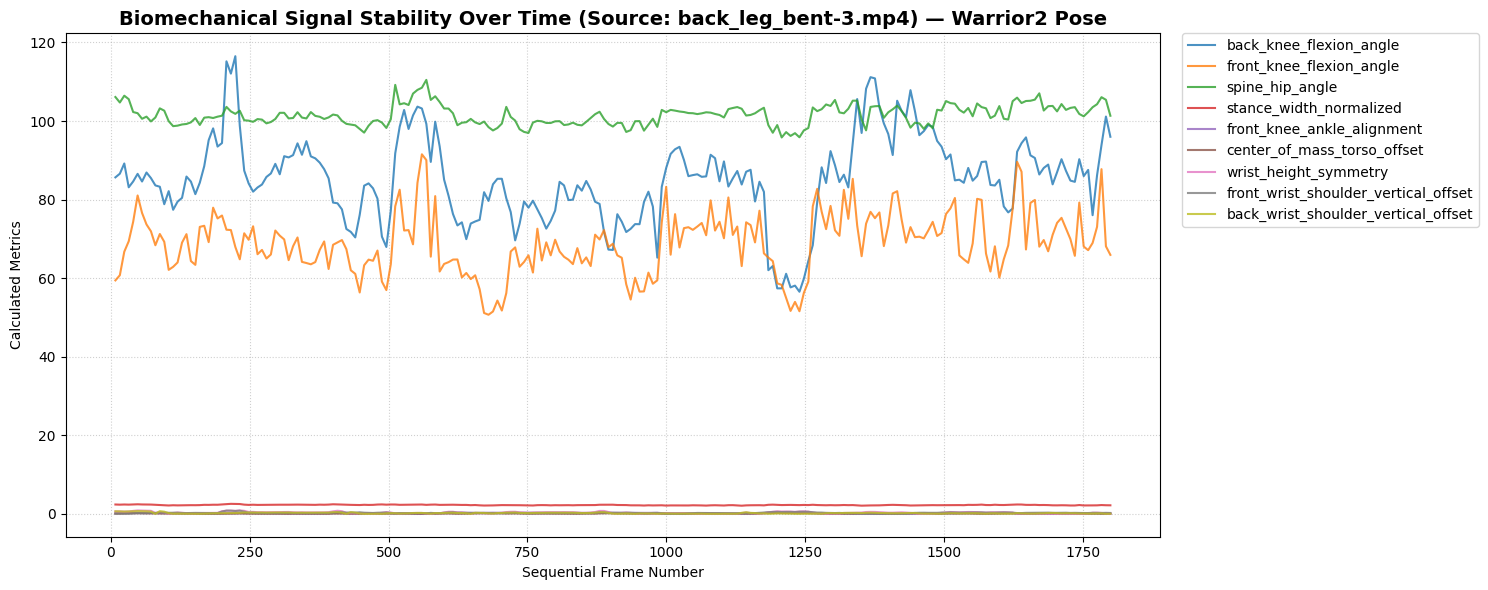

In [47]:
plot_signal_stability_over_time(cleaned_warrior2_df, pose_name="Warrior2 Pose")
